In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [15]:
PROJECT_ROOT = Path("/Users/elenipapadopulos/Desktop/PhD/Logical_structure_XAI")
RESULTS_ROOT = PROJECT_ROOT / "results" / "distilbert-base-uncased-finetuned-sst-2-english"
METHODS      = ["Occlusion", "Shap", "LIME"]

### Set config

In [55]:
CONFIGS = [
    ("base",        "sentence_not_1",             "base n=1",        {-2: "not"}),
    ("base",        "sentence_not_2",             "base n=2",        {-3: "first not", -2: "second not"}),
    ("base",        "sentence_not_3",             "base n=3",        {-4: "first not", -3: "second not", -2: "third not"}),
    ("contraction", "sentence_not_1_contraction", "contraction n=1", {-2: "not"}),
    ("contraction", "sentence_not_2_contraction", "contraction n=2", {-3: "first not", -2: "second not"}),
    ("not_start",   "sentence_not_beginning",     "not_at",          {0: "not"}),
    #("not_start",   "sentence_not_2_beginning",   "not_at n=2",      {-3: "first not", -2: "second not"}),
    ("aux_not",     "sentence_not_0_aux",         "aux n=0",         {2: "aux not"}),
    ("aux_not",     "sentence_not_1_aux",         "aux n=1",         {2: "aux not", -2: "adj not"}),
    #("aux_not",     "sentence_not_2_aux",         "aux n=2",         {2: "aux not", -3: "first adj not", -2: "second adj not"}),
]

PALETTE = ["#e94560", "#0f9b8e", "#f5a623", "#7b68ee", "#50fa7b", "#ff79c6"]

plt.rcParams.update({
    "font.family": "Arial",                
    "font.size": 16,                       
    "axes.titlesize": 18,                  
    "axes.labelsize": 16,                  
    "xtick.labelsize": 10,                  
    "ytick.labelsize": 10,                  
    "legend.fontsize": 10,                  
    "figure.titlesize": 14,                
    "lines.linewidth": 1.5,                
    "lines.markersize": 5,                 
    "savefig.dpi": 300,                    
    "savefig.bbox": "tight",               
    "figure.autolayout": True,             
    "axes.grid": False,                    
    "axes.linewidth": 0.8,                 
    "text.usetex": False,                   
})

### Utils

In [61]:
def plot_not_attribution(model_name):
    results_root = PROJECT_ROOT / "results" / model_name

    for folder, filename, label, positions in CONFIGS:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"'not' attribution  —  {label}  —  {model_name}",
                     fontweight="bold", color="black", y=1.02)

        for ax, method in zip(axes, METHODS):
            ax.set_title(method, fontweight="bold", pad=10)
            ax.set_xlabel("Feature importance")
            ax.set_ylabel("Density")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            path = results_root / method / folder / f"{filename}.pkl"
            if not path.exists():
                print(f"Missing: {path}")
                continue

            with open(path, "rb") as f:
                distrib = pickle.load(f)

            for j, (pos, pos_label) in enumerate(positions.items()):
                scores = [arr[pos] for arr in distrib]
                sns.kdeplot(scores, ax=ax, cut=0, fill=True, alpha=0.2,
                            color=PALETTE[j], linestyle="--", linewidth=2, label=pos_label)

            ax.legend()
            ax.set_xlim(0, 1)

        plt.tight_layout()
        os.makedirs(f"plots/{model_name}", exist_ok=True)
        plt.savefig(f"plots/{model_name}/{label.replace(' ', '_')}.png", facecolor="white")
        plt.show()

MODELS = {"roberta": "siebert/sentiment-roberta-large-english", "distilbert": "distilbert-base-uncased-finetuned-sst-2-english"}

## RoBERTa

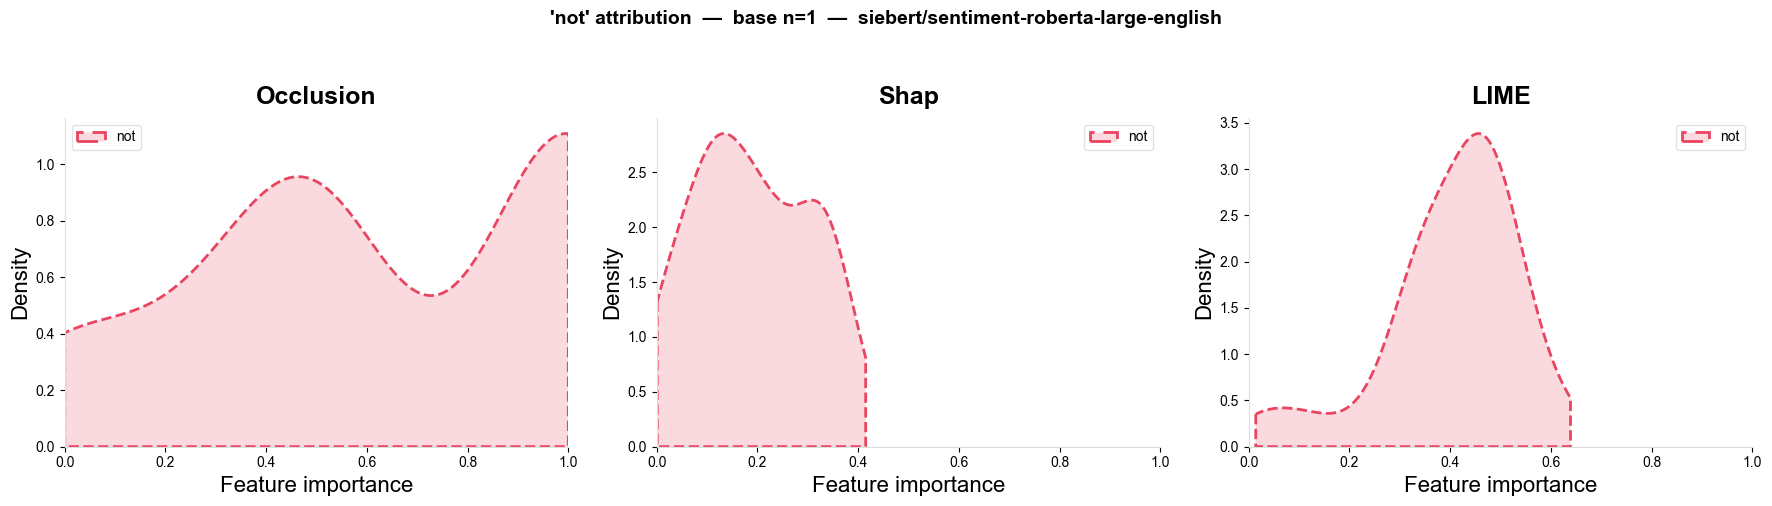

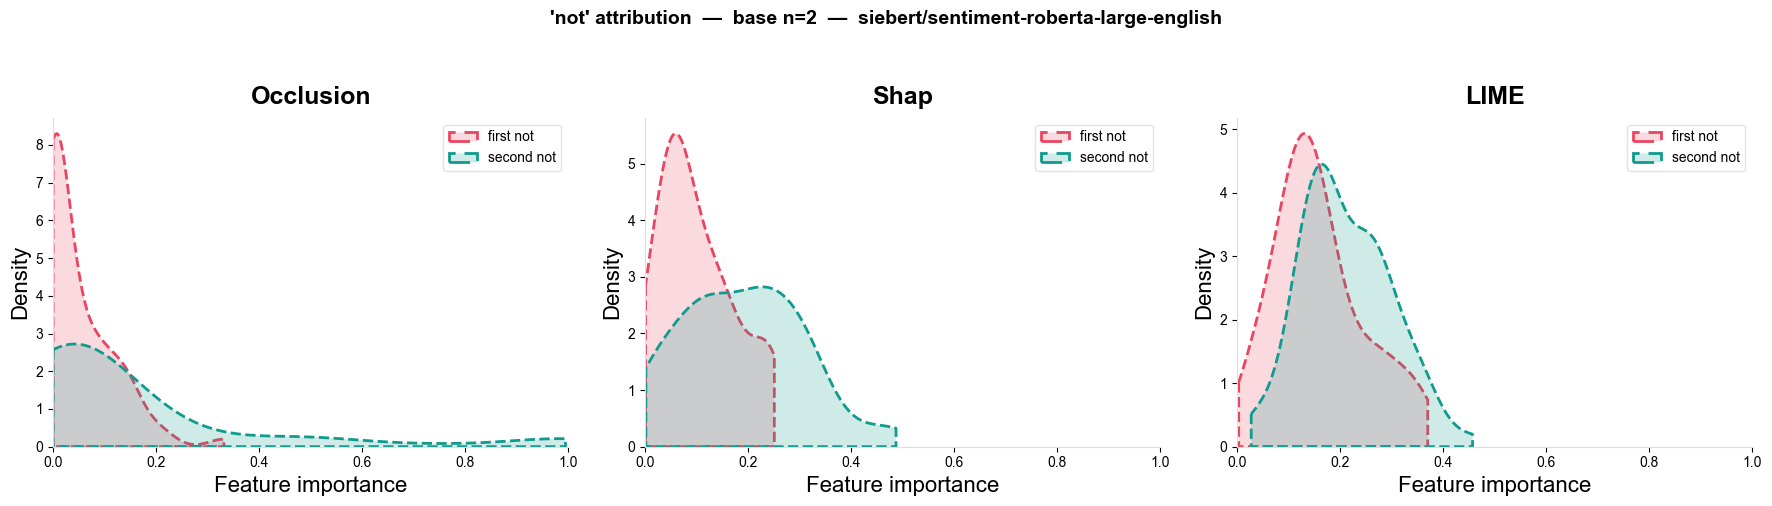

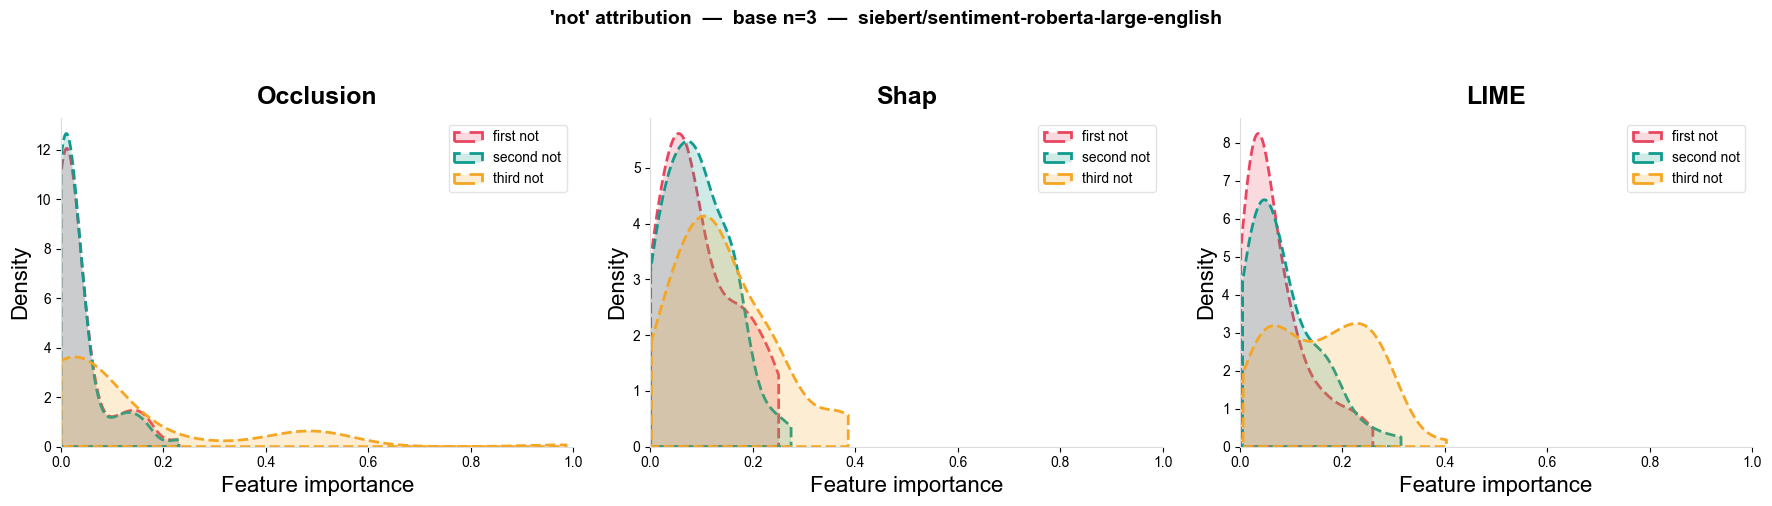

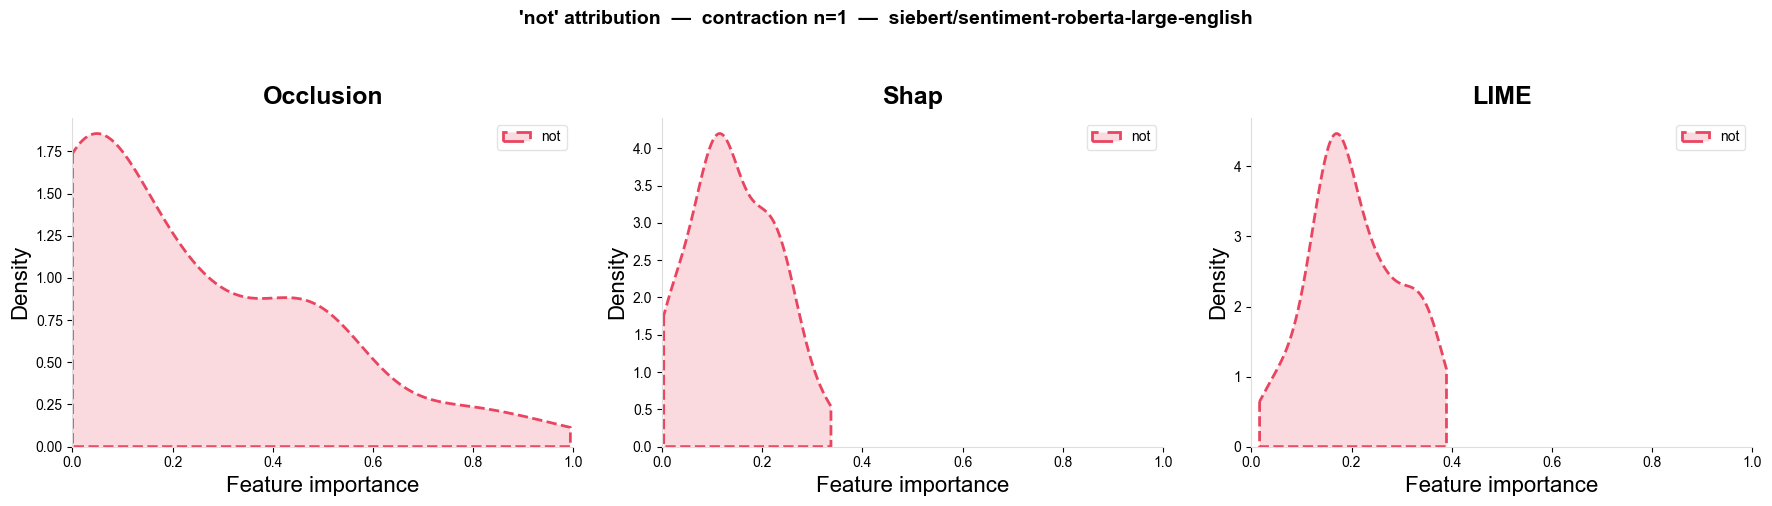

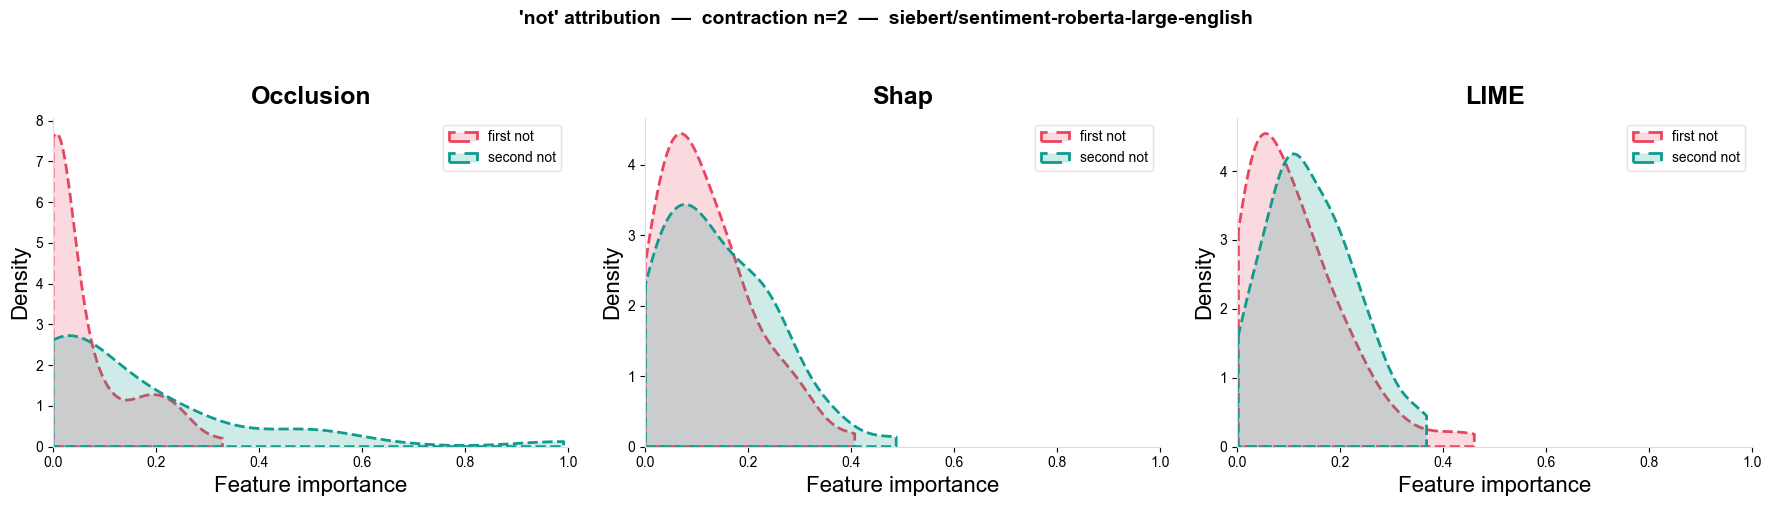

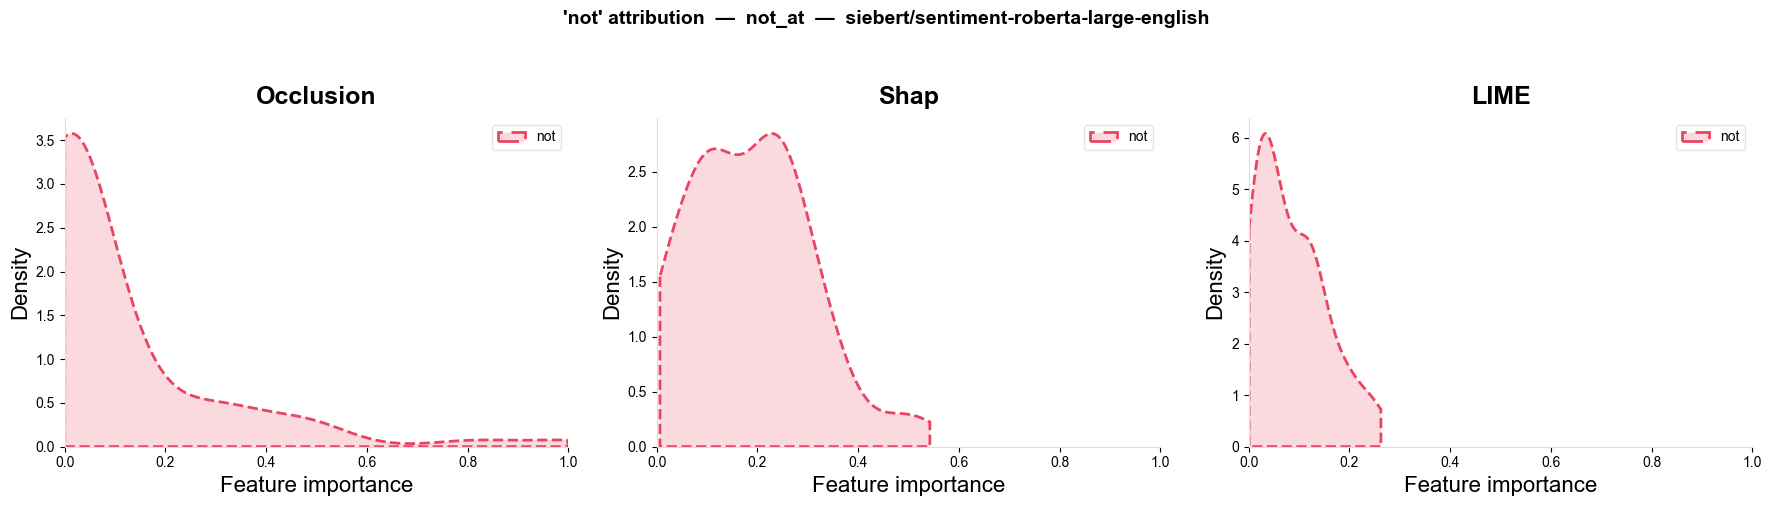

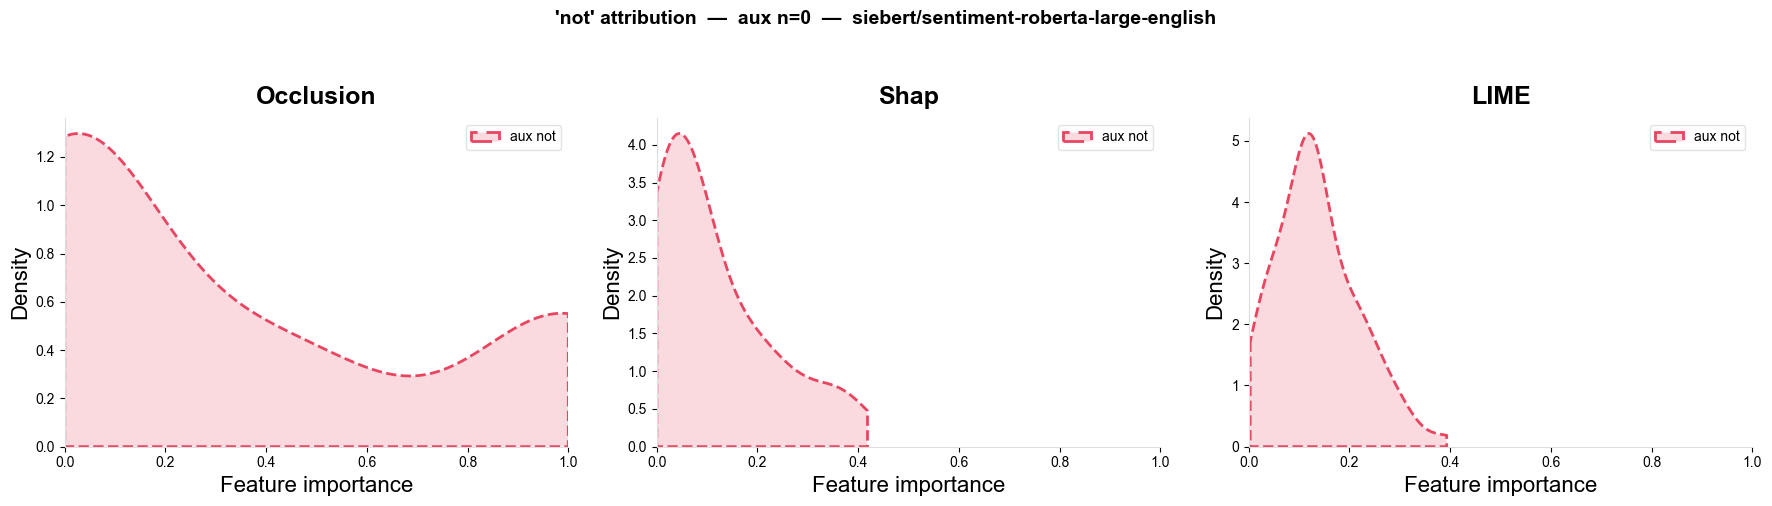

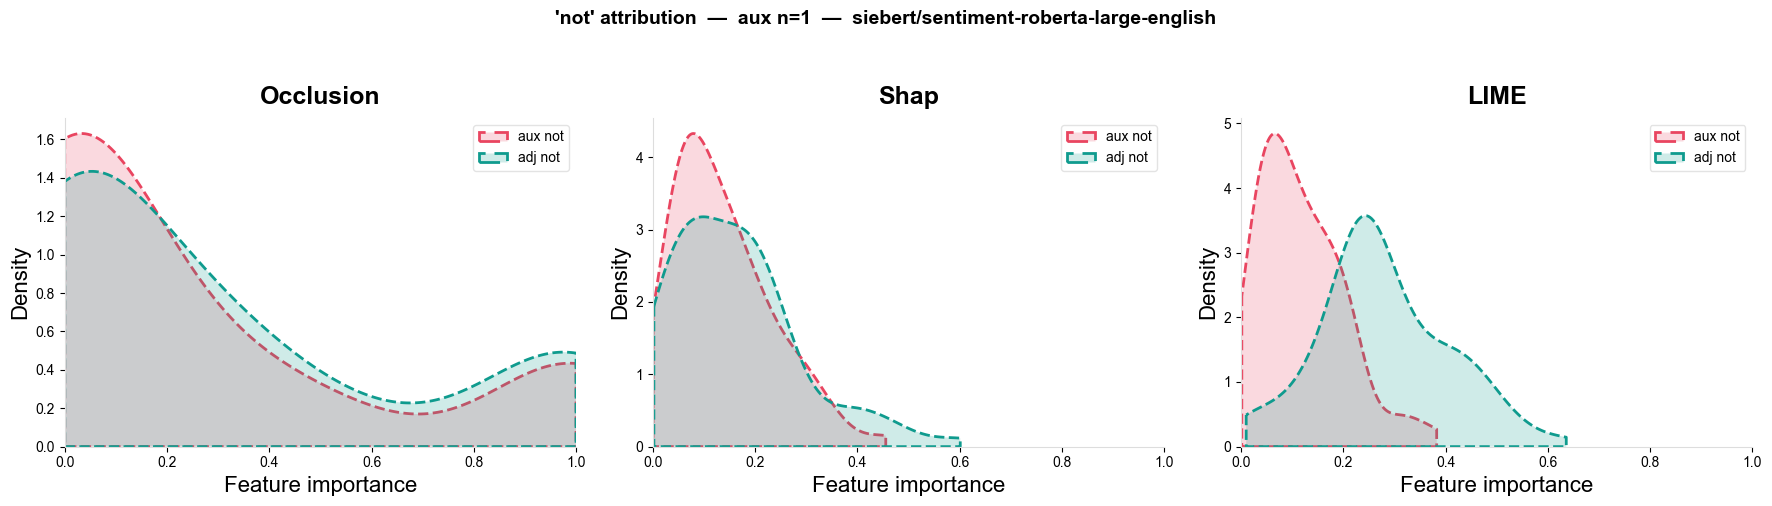

In [62]:
plot_not_attribution(MODELS["roberta"])

## DistilBERT

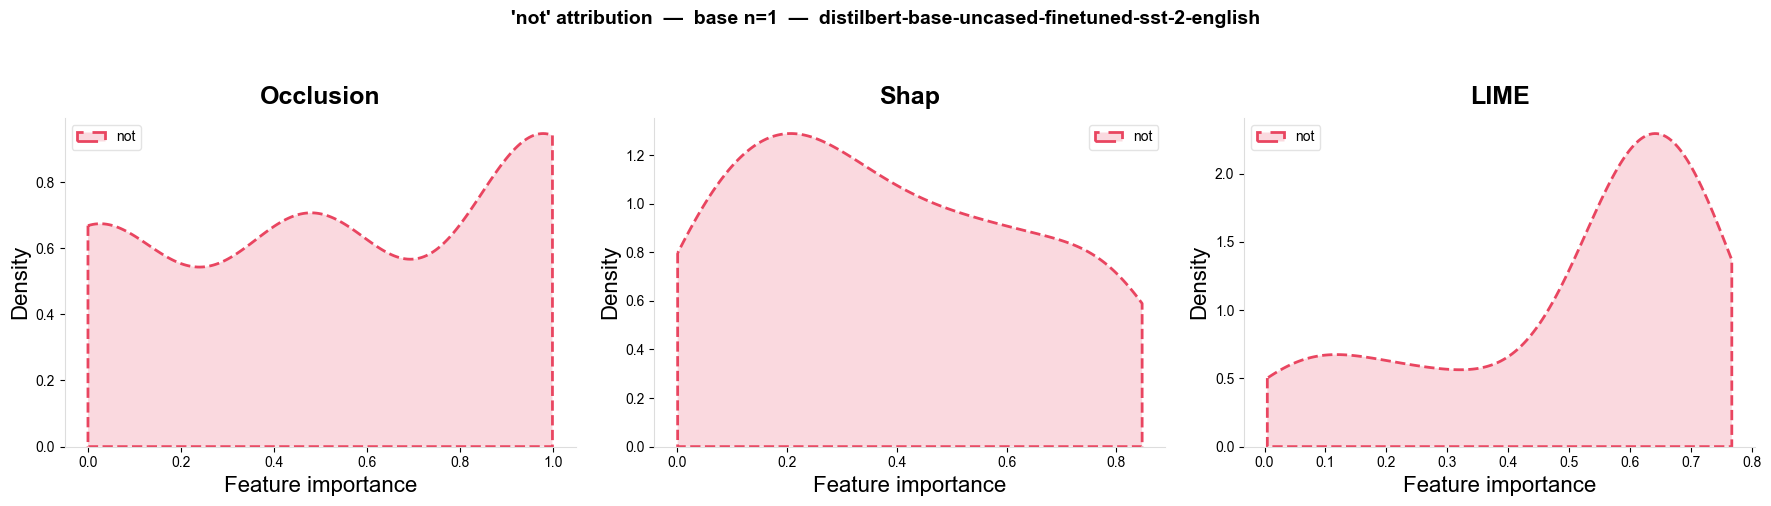

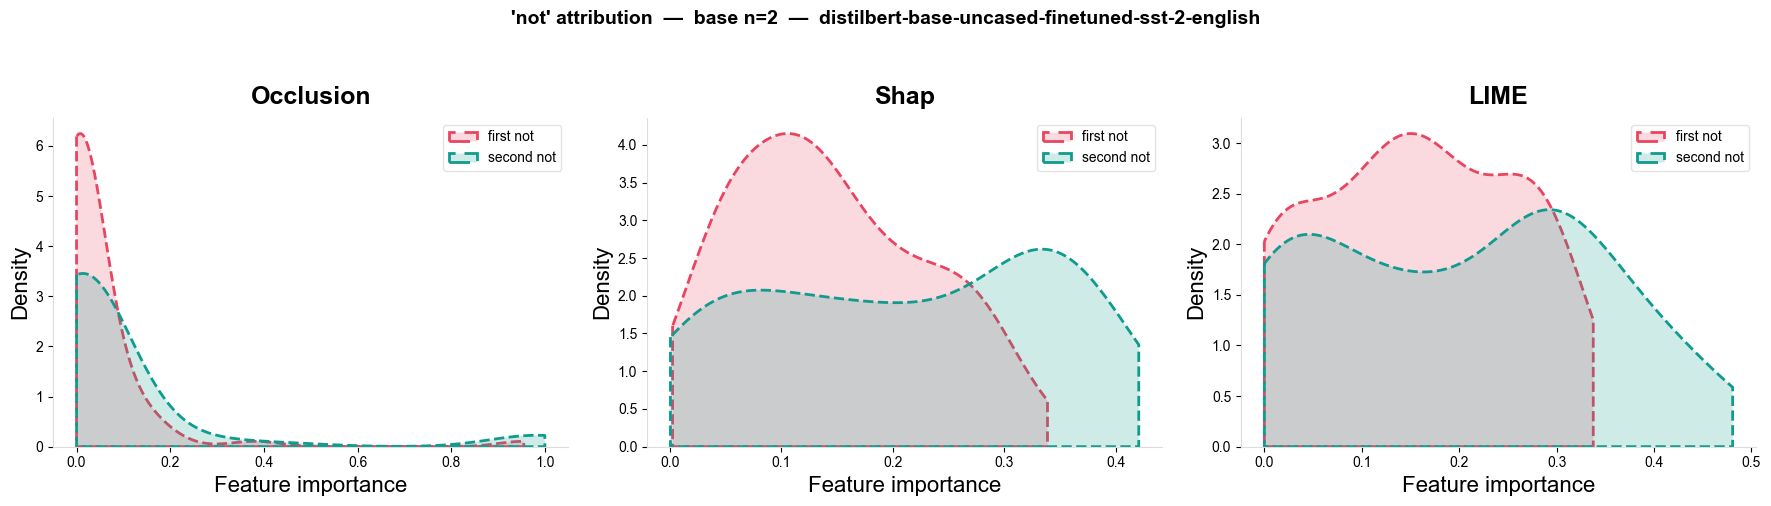

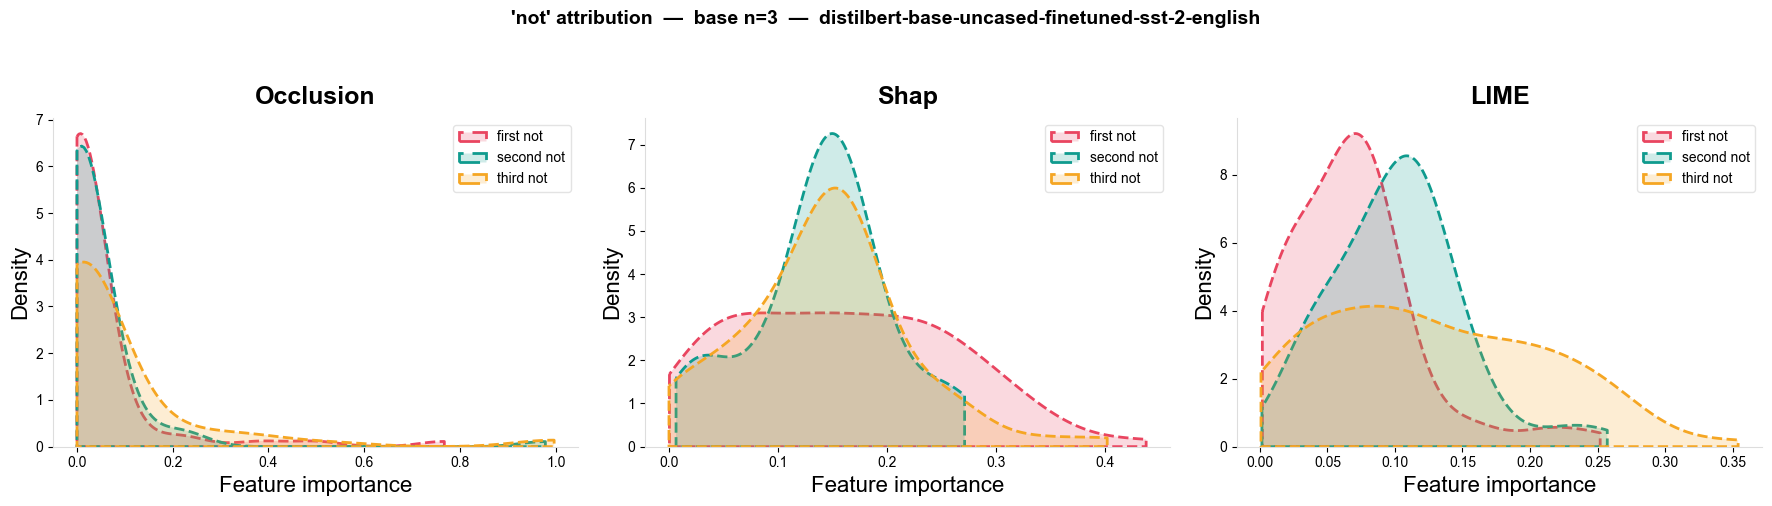

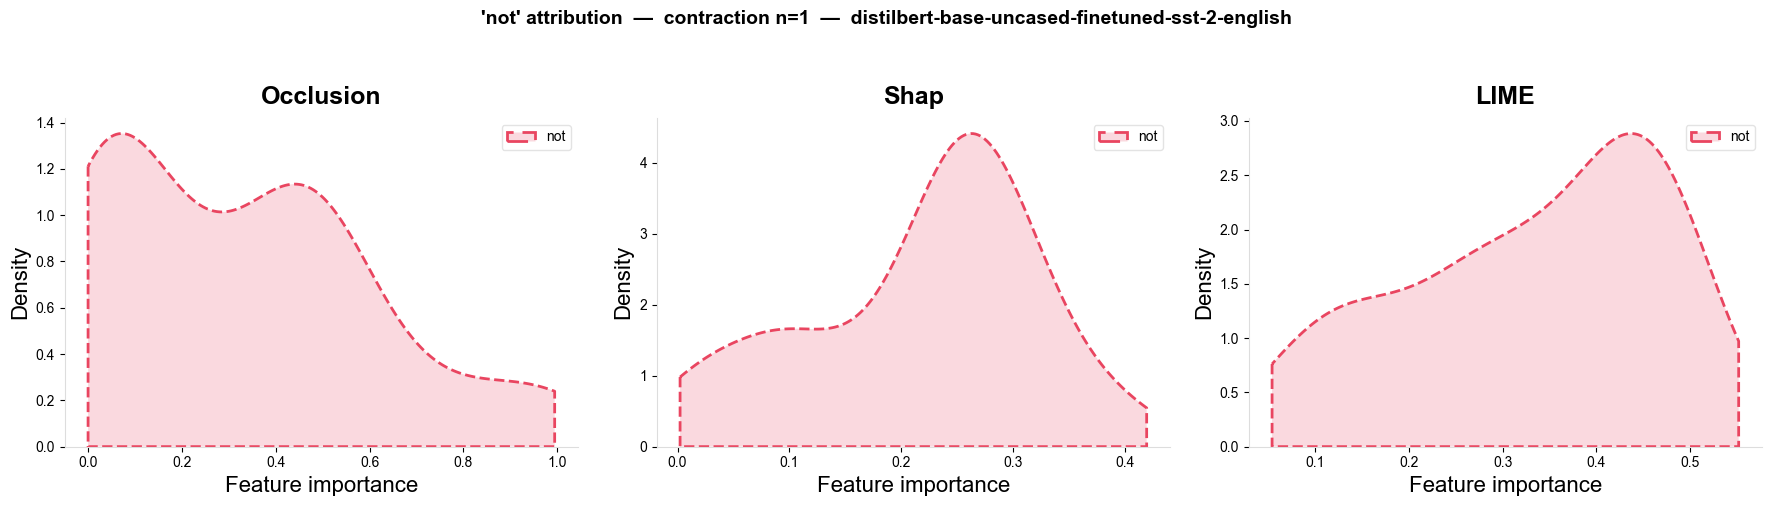

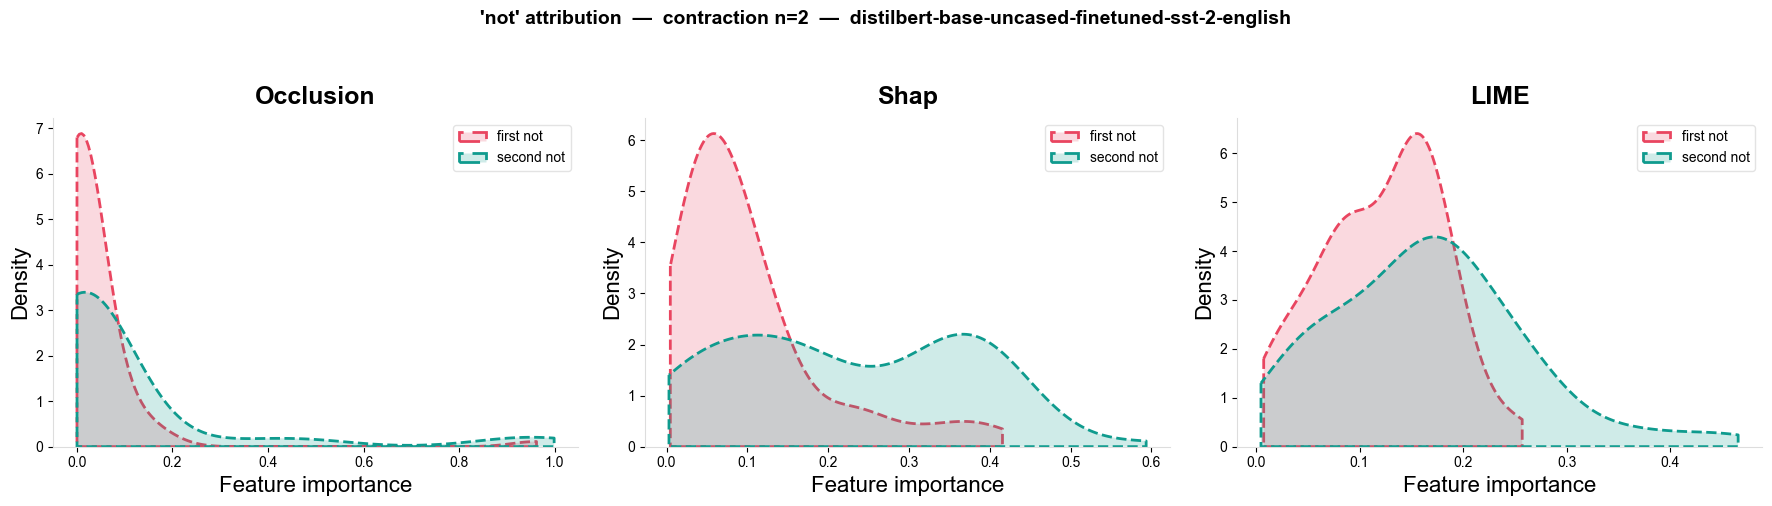

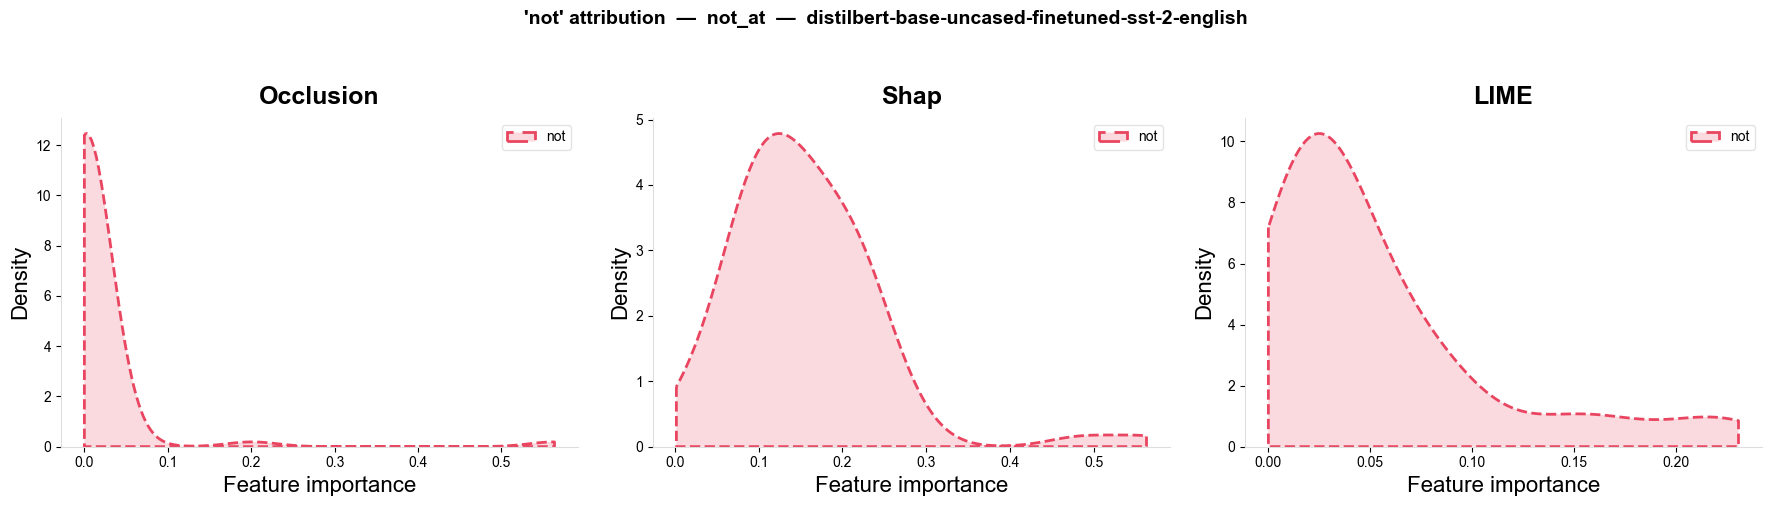

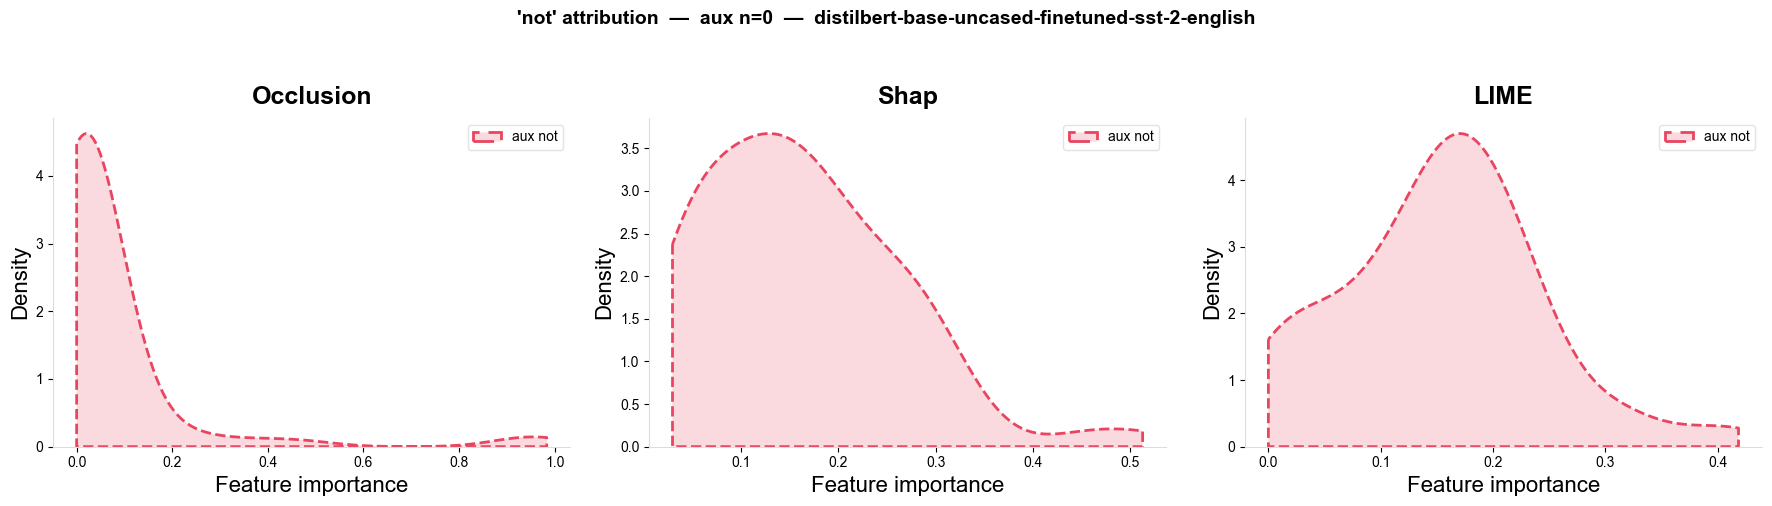

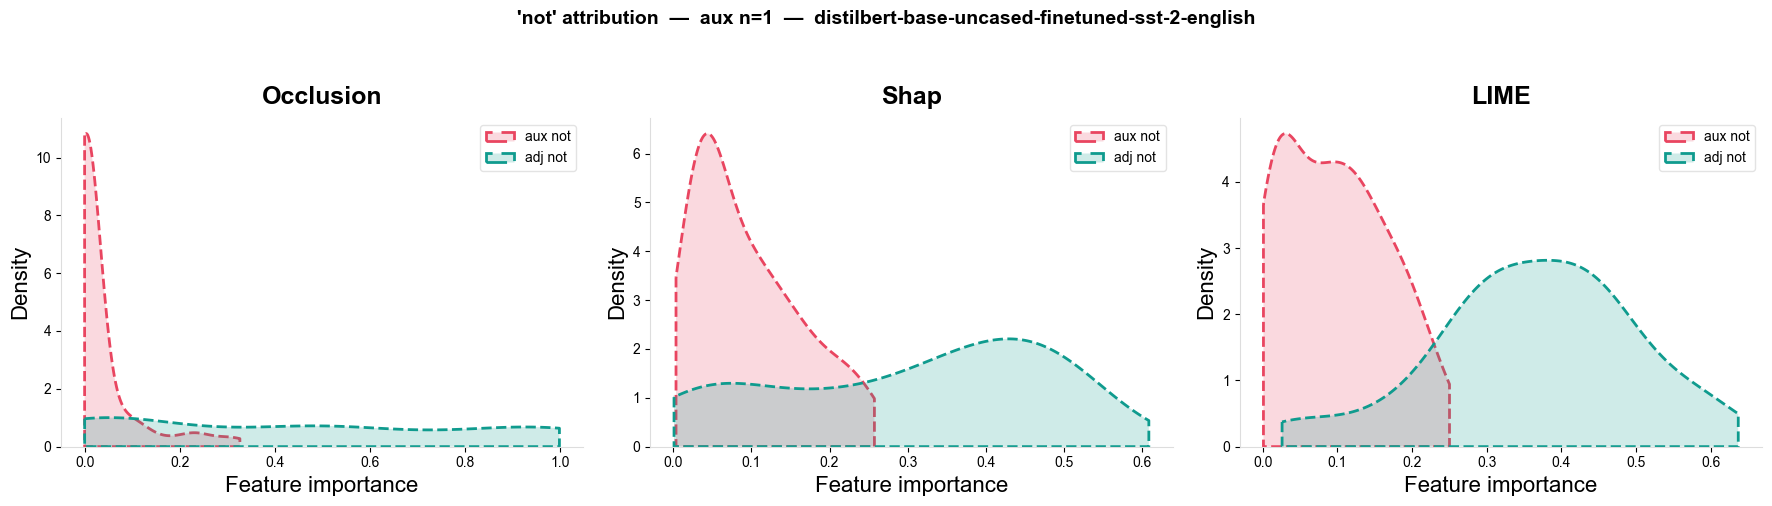

In [60]:
plot_not_attribution(MODELS["distilbert"])